Note: Using all businesses as sample facilities for this exercise
Power plants/facilities loaded: 50

Columns available: ['business_id', 'business_name', 'province', 'district', 'urban_rural', 'industry_code', 'industry_desc', 'legal_status', 'year_established', 'n_employees', 'size_class', 'annual_turnover', 'is_registered', 'has_tax_id', 'latitude', 'longitude', 'facility_type']
Coordinate columns:
  Latitude range: -18.59 to -11.53
  Longitude range: 22.33 to 35.43
Original CRS: EPSG:4326
Web Mercator CRS: EPSG:3857
Provinces CRS: EPSG:3857


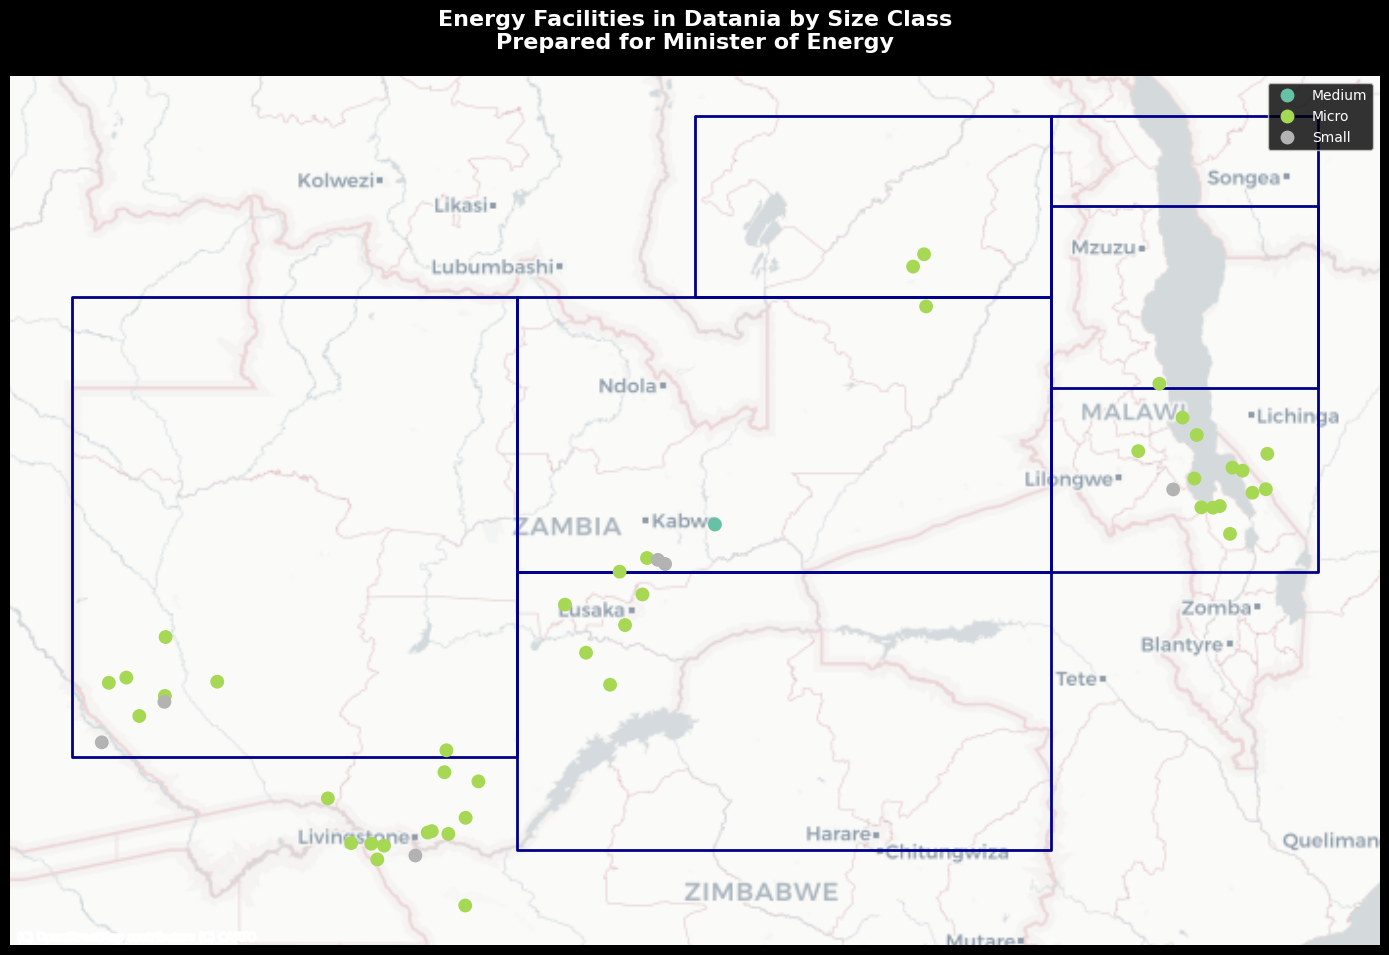

Map saved as 'datania_power_plants.png'


In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
import contextily as cx
import datania

# Load business register and filter to energy sector
business_csv = datania.generate_business_register(n_businesses=150, seed=77)
businesses = pd.read_csv(business_csv)

# Filter to energy-related businesses (simulating power plants)
# Industry code 'D' = Electricity, gas, water supply
power_plants = businesses[businesses['industry_code'] == 'D'].copy()

# If we don't have enough energy businesses, use all businesses as "facilities"
if len(power_plants) < 20:
    print("Note: Using all businesses as sample facilities for this exercise")
    power_plants = businesses.head(50).copy()
    power_plants['facility_type'] = power_plants['industry_code'].map({
        'A': 'Agricultural', 'C': 'Industrial', 'G': 'Commercial',
        'F': 'Construction', 'I': 'Services'
    }).fillna('Other')

print(f"Power plants/facilities loaded: {len(power_plants)}")
print(f"\nColumns available: {power_plants.columns.tolist()}")
power_plants.head()
# Task 1: Verify we have latitude and longitude columns
# YOUR CODE HERE - check the coordinate columns exist
print("Coordinate columns:")
print(f"  Latitude range: {power_plants['latitude'].min():.2f} to {power_plants['latitude'].max():.2f}")
print(f"  Longitude range: {power_plants['longitude'].min():.2f} to {power_plants['longitude'].max():.2f}")
# Task 2: Convert to GeoDataFrame and reproject to Web Mercator

# Step 2a: Create Point geometries (remember: lon, lat order!)
geometry = [Point(lon, lat) for lon, lat in
            zip(power_plants['longitude'], power_plants['latitude'])]

# Step 2b: Create GeoDataFrame with WGS84 CRS
power_plants_gdf = gpd.GeoDataFrame(power_plants, geometry=geometry, crs="EPSG:4326")

# Step 2c: Convert to Web Mercator for contextily compatibility
# YOUR CODE HERE
power_plants_web = # Use .to_crs() to convert to EPSG:3857

print(f"Original CRS: {power_plants_gdf.crs}")
print(f"Web Mercator CRS: {power_plants_web.crs}")
# Task 3: Create province boundaries (simplified for this exercise)
from shapely.geometry import box

provinces_data = {
    'province_code': ['NTH', 'STH', 'EST', 'WST', 'CTR', 'LKS'],
    'province_name': ['Northern', 'Southern', 'Eastern', 'Western', 'Central', 'Lakeside'],
    'geometry': [
        box(29, -12, 33, -10),  # Northern
        box(27, -18, 33, -15),  # Southern
        box(33, -15, 36, -11),  # Eastern
        box(22, -17, 27, -12),  # Western
        box(27, -15, 33, -12),  # Central
        box(33, -13, 36, -10),  # Lakeside
    ]
}

provinces_gdf = gpd.GeoDataFrame(provinces_data, crs="EPSG:4326")

# YOUR CODE HERE - convert provinces to Web Mercator too
provinces_web = # Convert to EPSG:3857

print(f"Provinces CRS: {provinces_web.crs}")
# Task 4: Build the multi-layer map
fig, ax = plt.subplots(figsize=(14, 12))

# Layer 1: Province boundaries (middle layer)
# YOUR CODE HERE - plot provinces with:
#   - facecolor='none' (transparent fill)
#   - edgecolor='darkblue'
#   - linewidth=2
#   - zorder=2
provinces_web.plot(
    ax=ax,
    # Add your parameters here
)

# Layer 2: Power plants colored by size_class (top layer)
# YOUR CODE HERE - plot power plants with:
#   - column='size_class' (or 'legal_status')
#   - cmap='Set2' (or another colormap)
#   - markersize=80
#   - legend=True
#   - zorder=3
power_plants_web.plot(
    ax=ax,
    # Add your parameters here
)

# Layer 3: Basemap (appears at bottom even though added last)
# YOUR CODE HERE - add CartoDB Positron basemap
# Hint: cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)


# Finishing touches
ax.set_title('Energy Facilities in Datania by Size Class\nPrepared for Minister of Energy',
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()  # Hide axis numbers for cleaner look

plt.tight_layout()
plt.show()
# Task 5: Save as high-resolution PNG for the report
# YOUR CODE HERE
# Hint: fig.savefig('datania_power_plants.png', dpi=300, bbox_inches='tight')

print("Map saved as 'datania_power_plants.png'")
